In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

### Walmart Sales Analytics Dashboard
This dashboard provides a high-level overview of the sales performance across different dimensions like product lines, payment methods, and geographic locations.

### 1. Total Sales by Product Line

This bar chart compares the total sales volume across different product categories. It helps identify which departments (like Food & Beverages or Fashion) are driving the most revenue for Walmart.

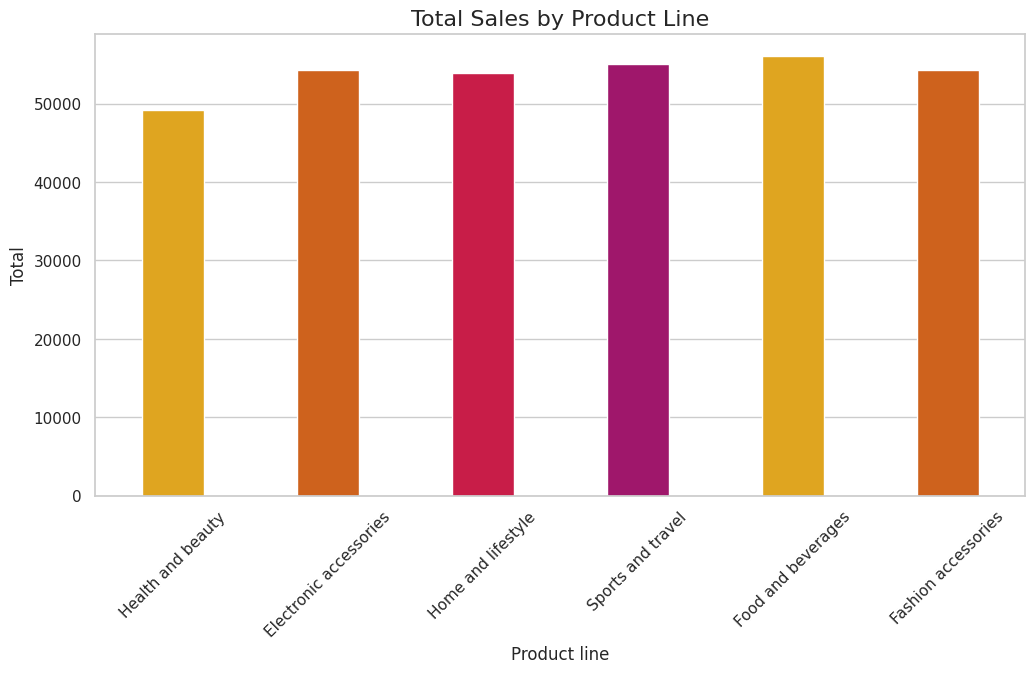

In [64]:
plt.figure(figsize=(12, 6))
# Defining the custom palette
custom_palette = ['#FFB200', '#EB5B00', '#E4003A', '#B60071']
sns.barplot(data=df, x='Product line', y='Total', estimator=sum, palette=custom_palette, ci=None, width=0.4)
plt.title('Total Sales by Product Line', fontsize=16)
plt.xticks(rotation=45)
plt.show()

### 2. Payment Method Distribution

This donut chart visualizes the popularity of different payment methods (Cash, Credit Card, and E-wallet). It provides insight into customer preferences for transaction types.

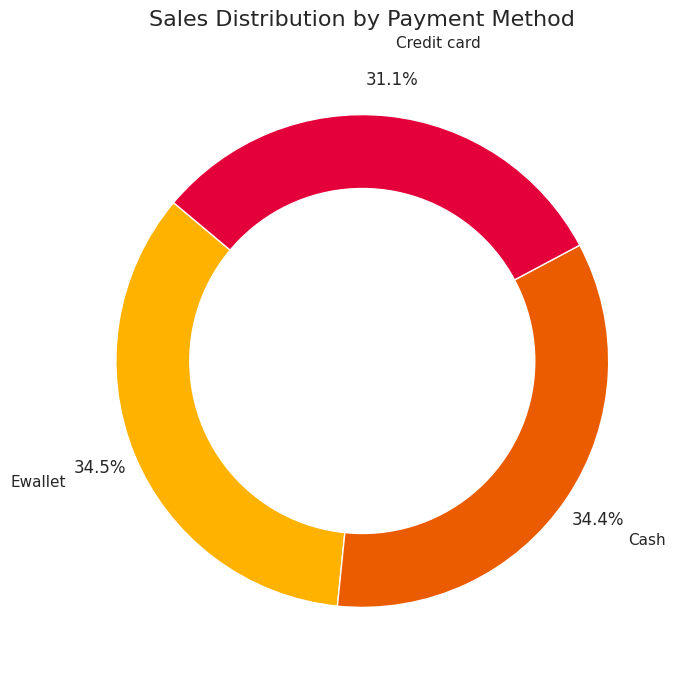

In [65]:
plt.figure(figsize=(8, 8))
payment_counts = df['Payment'].value_counts()
# Creating the pie chart base with values outside (pctdistance > 1)
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', colors=['#FFB200', '#EB5B00', '#E4003A'], startangle=140, pctdistance=1.15, labeldistance=1.3)
# Drawing a white circle at the center to create the 'donut' hole
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Sales Distribution by Payment Method', fontsize=16, pad=20)
plt.show()

### 3. Monthly Sales Trend

This line chart tracks sales performance over time (January to March). It is useful for identifying growth trends or seasonal dips in consumer spending.

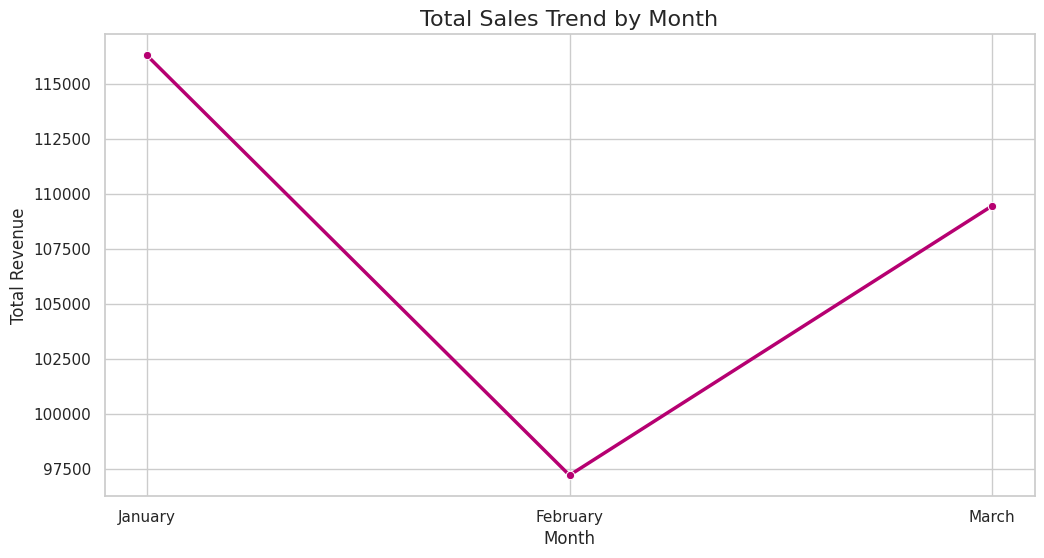

In [66]:
plt.figure(figsize=(12, 6))
monthly_sales = df.groupby('Month')['Total'].sum().reindex(['January', 'February', 'March'])
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o', color='#B60071', linewidth=2.5)
plt.title('Total Sales Trend by Month', fontsize=16)
plt.ylabel('Total Revenue')
plt.show()

### 4. Average Customer Rating

This horizontal bar chart breaks down customer satisfaction ratings by city and customer type (Member vs. Normal). It highlights which locations and customer segments are most satisfied with their experience.

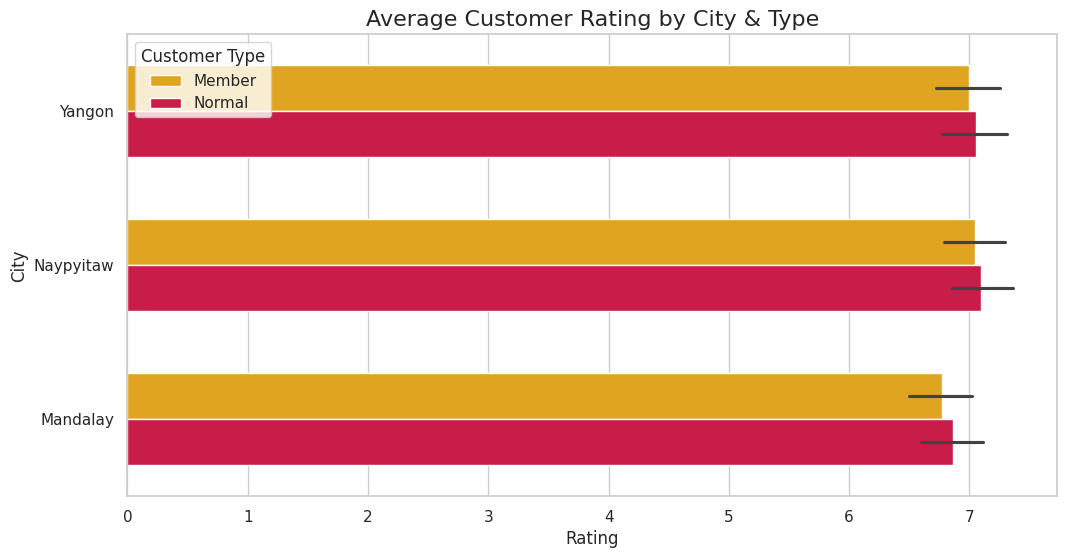

In [67]:
plt.figure(figsize=(12, 6))
# Swapping x and y to create a horizontal bar chart and reducing bar width
sns.barplot(data=df, x='Rating', y='City', hue='Customer type', palette=['#FFB200', '#E4003A'], width=0.6)
plt.title('Average Customer Rating by City & Type', fontsize=16)
plt.legend(title='Customer Type')
plt.show()

### 5. Sales Performance by Branch
Comparing total sales across the three different branches (A, B, and C).

This boxplot shows the distribution and spread of transaction totals across branches A, B, and C. It helps identify outliers and the typical spending range at each location.

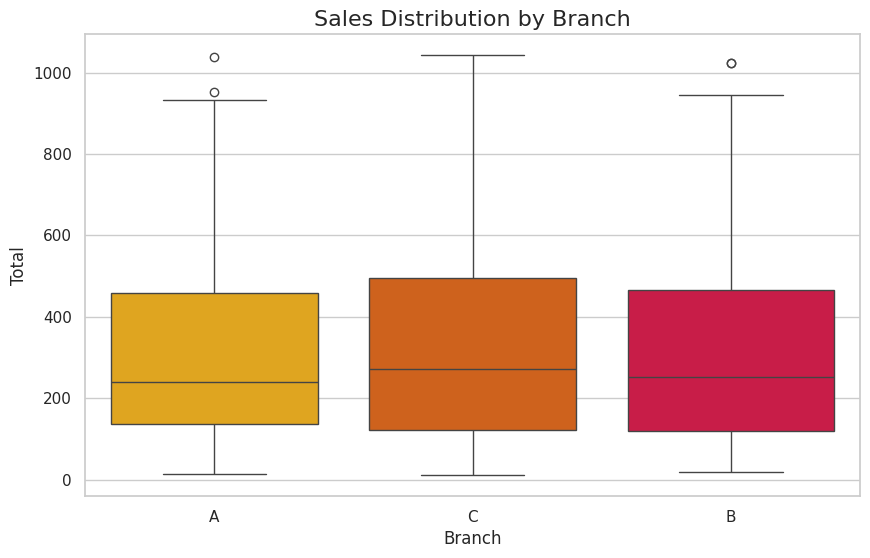

In [68]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Branch', y='Total', palette=['#FFB200', '#EB5B00', '#E4003A'])
plt.title('Sales Distribution by Branch', fontsize=16)
plt.show()

### 6. Unit Price vs. Quantity
Analyzing if there is any correlation between the price of an item and the quantity purchased.

This line chart displays the average price of items sold in each product line. It helps us understand which categories are positioned as 'premium' or 'high-value' versus budget-friendly.

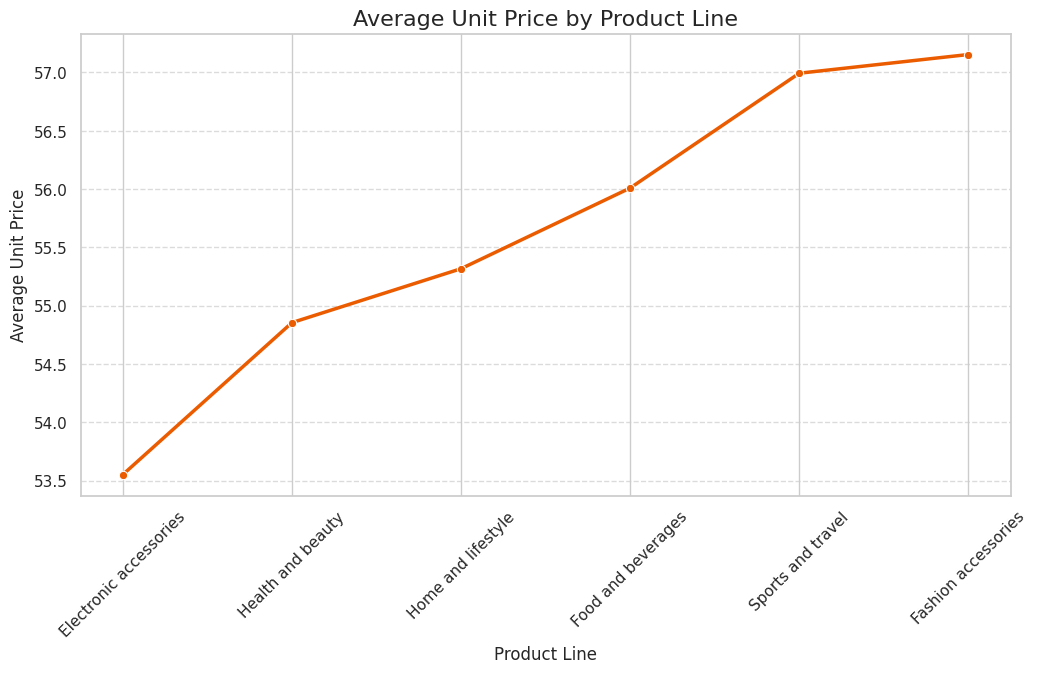

In [69]:
plt.figure(figsize=(12, 6))
# Grouping by Product line to show a line chart trend of average unit prices
avg_unit_price = df.groupby('Product line')['Unit price'].mean().sort_values()
sns.lineplot(x=avg_unit_price.index, y=avg_unit_price.values, marker='o', color='#EB5B00', linewidth=2.5)
plt.title('Average Unit Price by Product Line', fontsize=16)
plt.xlabel('Product Line')
plt.ylabel('Average Unit Price')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 7. Product Line Preference by Gender
Visualizing which product lines are most popular among different genders.

This count plot compares product line popularity between Male and Female customers. It is essential for targeted marketing and inventory management based on gender-specific buying patterns.

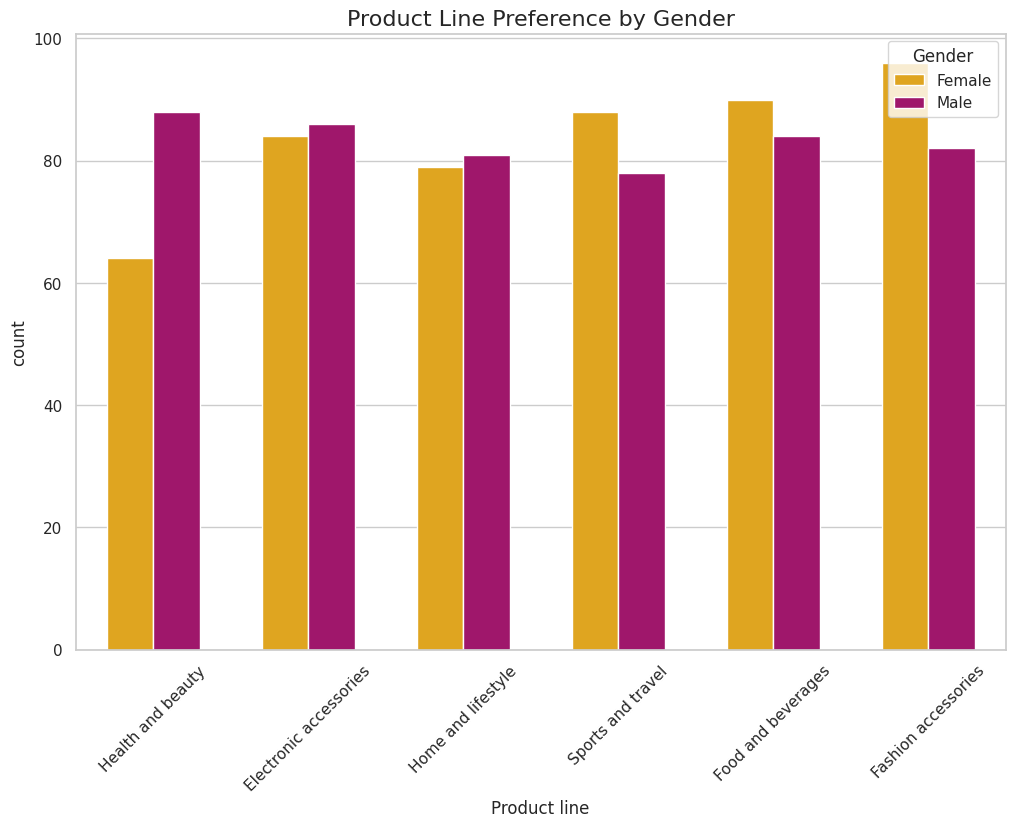

In [70]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='Product line', hue='Gender', palette=['#FFB200', '#B60071'], width=0.6)
plt.title('Product Line Preference by Gender', fontsize=16)
plt.xticks(rotation=45)
plt.legend(title='Gender', loc='upper right')
plt.show()

### 8. Distribution of Total Sales
Visualizing the distribution of transaction totals to identify common spending patterns.

This histogram with a Kernel Density Estimate (KDE) shows how frequently different transaction amounts occur. Most transactions cluster at the lower end, showing the typical basket size.

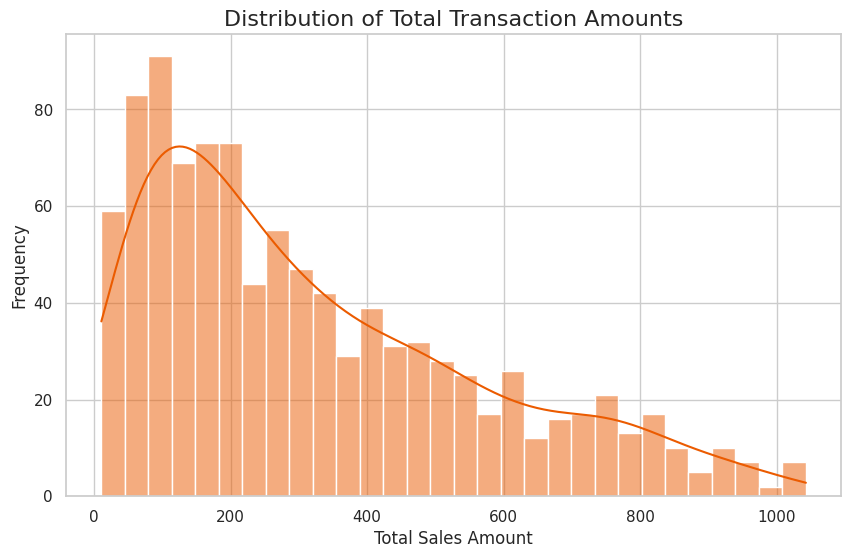

In [71]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Total'], kde=True, color='#EB5B00', bins=30)
plt.title('Distribution of Total Transaction Amounts', fontsize=16)
plt.xlabel('Total Sales Amount')
plt.ylabel('Frequency')
plt.show()

### 9. Correlation Heatmap
Analyzing the relationships between numerical features in the dataset.

The heatmap shows the correlation between numerical variables like Unit Price, Quantity, and Tax. High correlation coefficients (near 1.0) indicate variables that move strongly together.

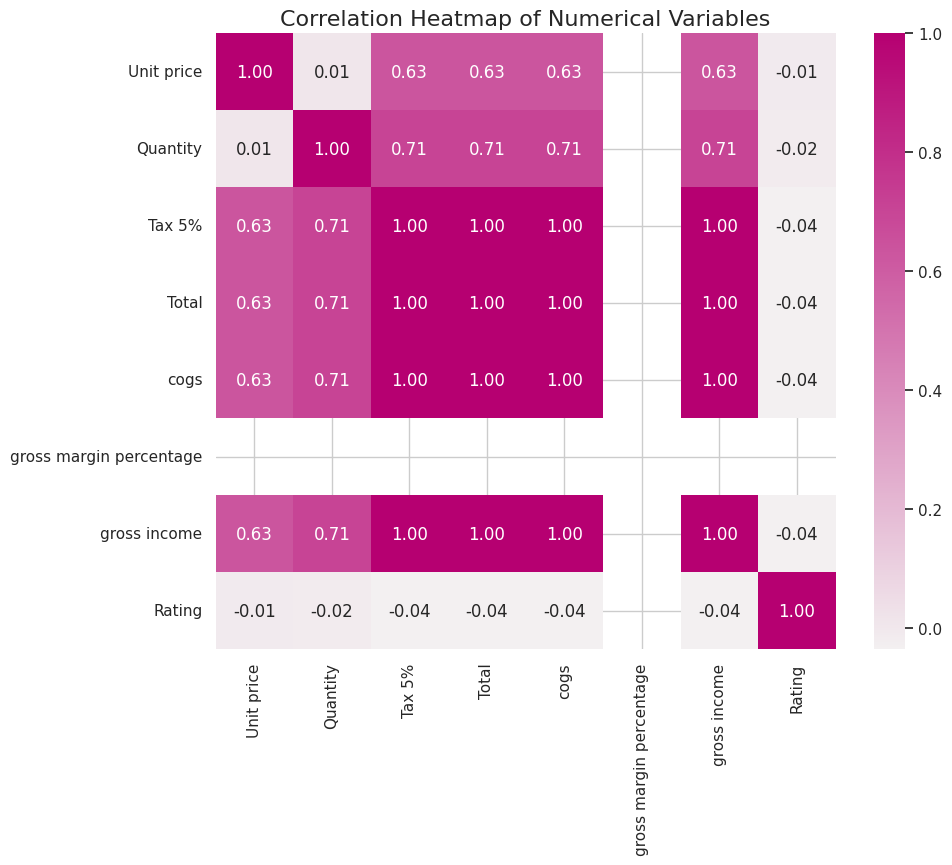

In [72]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap=sns.light_palette('#B60071', as_cmap=True), fmt='.2f')
plt.title('Correlation Heatmap of Numerical Variables', fontsize=16)
plt.show()

### 10. Gross Income by City
Comparing the total gross income generated across the three major cities.

This vertical bar chart compares the total profit (gross income) generated by each city. It clearly shows which geographic region is the most profitable for the business.

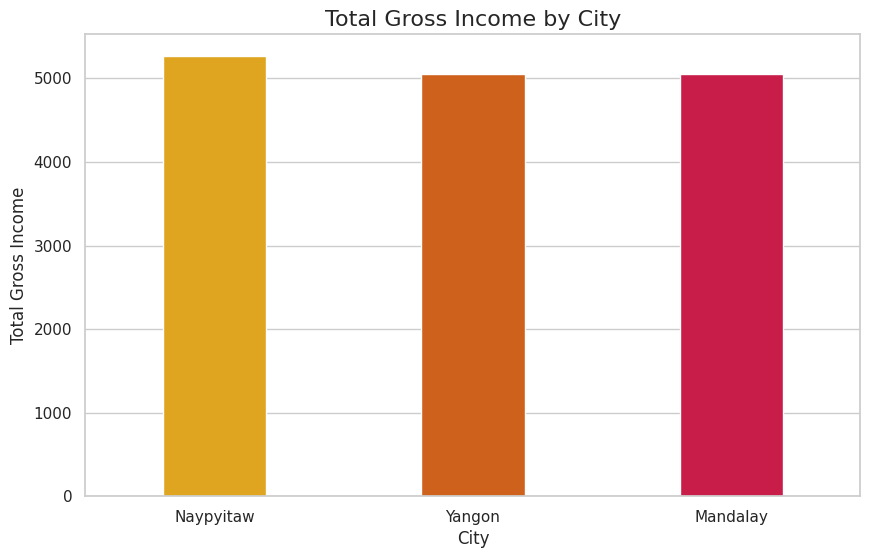

In [73]:
plt.figure(figsize=(10, 6))
city_income = df.groupby('City')['gross income'].sum().sort_values(ascending=False)
sns.barplot(x=city_income.index, y=city_income.values, palette=['#FFB200', '#EB5B00', '#E4003A'], width=0.4)
plt.title('Total Gross Income by City', fontsize=16)
plt.xlabel('City')
plt.ylabel('Total Gross Income')
plt.show()